In [36]:
import os
import glob
import json
import tifffile 
import numpy 

from matplotlib import pyplot, colors
from skimage import filters, measure
from collections import defaultdict
from tqdm.auto import tqdm

from wavelet import detect_spots

from stedfm.DEFAULTS import BASE_PATH
from stedfm.utils import savefig

DATASET = "als-experiment-synthetic"
TEMPLATE = "template-perforated"

cmap = colors.LinearSegmentedColormap.from_list("dodgerblue-fuchsia", ["dodgerblue", "fuchsia"], N=6)

COLORS = {
    "DIV12" : "dodgerblue",
    "DIV25" : "fuchsia",
    "sDIV12" : "dodgerblue",
    "sDIV25" : "fuchsia",
    **{f"{i}" : cmap(i / 6) for i in range(1, 7)}
}

with open(os.path.join(BASE_PATH, "results", "detection-experiments", "MAE_SMALL_STED", TEMPLATE, DATASET, "metadata.json")) as f:
    metadata = json.load(f)

for key, values in metadata.items():
    print(key, len(values))

examples 434


In [32]:
if "DIV12" not in metadata or "DIV25" not in metadata:
    groups = defaultdict(list)
    for item in metadata["examples"]:
        group = os.path.basename(item["image-name"]).split("_")[-1]
        group = ".".join(group.split(".")[:-1])
        if group not in ["1.05", "0.65", "0.24", "-0.17", "-0.57", "-0.98"]:
            continue
        if group == "0":
            continue
        
        if group not in ["1", "2", "3", "4", "5", "6"]:
            group = "sDIV12" if float(group) > 0 else "sDIV25"

        groups[group].append(item)
    for key, values in groups.items():
        print(key, len(values))
    metadata = groups

sDIV12 187
sDIV25 186


In [33]:
def get_dendrite_foreground(img):
    """Gets the foreground of the dendrite channel using a gaussian blur of
    sigma = 20 and the otsu threshold.

    :param img: A 3D numpy

    :returns : A binary 2D numpy array of the foreground
    """
    blurred = filters.gaussian(img[2], sigma=20)
    blurred /= blurred.max()
    val = filters.threshold_otsu(blurred)
    return (blurred > val).astype(int)

def validate_rprop_in_foreground(rprop, foreground):
    """
    Validates that the region properties are touching the foreground.

    :param rprops: A list of region properties
    :param foreground: A binary 2D numpy array of the foreground
    """
    coords = rprop.coords
    if numpy.any(foreground[coords[:, 0], coords[:, 1]] == 1):
        return True
    return False

def label_image_from_rprops(rprops, shape):
    """
    Creates a labeled image from region properties.

    :param rprops: A list of region properties
    :param shape: The shape of the image

    :returns : A labeled image
    """
    label = numpy.zeros(shape, dtype=int)
    for i, rprop in enumerate(rprops):
        coords = rprop.coords
        label[coords[:, 0], coords[:, 1]] = i + 1
    return label

def load_images(metadata, show=False, threshold=0.65):
    """
    Loads the images and optionaly displays them.

    :param metadata: A dictionary with the metadata
    :param show: A boolean to display

    :returns : A tuple with the foreground and the labeled image
    """
    original = tifffile.imread(os.path.join(BASE_PATH, metadata["original-path"]))
    foreground = detect_spots(original)

    # fg_intensity = original[foreground].mean()
    # if fg_intensity < 0.15:
    #     return None, None

    label_foreground = measure.label(foreground)

    prediction = tifffile.imread(os.path.join(BASE_PATH, metadata["savepath"]))[1]
    binarized = (prediction > threshold).astype(int)

    label = measure.label(binarized)
    rprops = measure.regionprops(label)
    # rprops = [rprop for rprop in rprops if validate_rprop_in_foreground(rprop, foreground)]
    label = label_image_from_rprops(rprops, binarized.shape)

    if show:
        fig, axes = pyplot.subplots(1, 4, figsize=(10, 5))
        axes[0].imshow(original, cmap="hot")
        axes[1].imshow(prediction, cmap="magma", vmin=0, vmax=threshold)
        axes[2].imshow(label)
        axes[3].imshow(foreground, cmap="gray")
        pyplot.show()

    return label_foreground, label

def compute_scores(foreground, label):
    """
    Computes the scores for the foreground and the label.

    :param foreground: A binary 2D numpy array of the foreground
    :param label: A labeled image

    :returns : A dictionary with the scores
    """
    fg_rprops = measure.regionprops(foreground)
    contains = 0
    for rprop in fg_rprops:
        coords = rprop.coords
        if numpy.any(label[coords[:, 0], coords[:, 1]] > 0):
            contains += 1
    ratio = contains / len(fg_rprops) if len(fg_rprops) > 0 else 0
    return {
        "ratio" : label.max() / foreground.max(),
        "num" : label.max(),
    }



sDIV12:   0%|          | 0/187 [00:00<?, ?it/s]

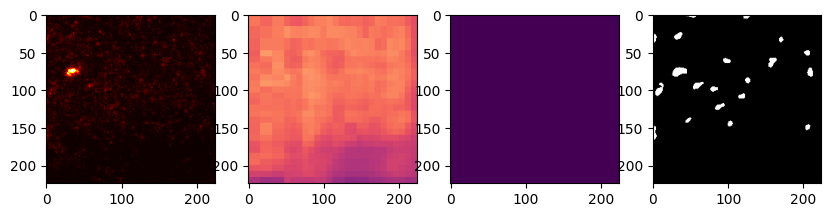

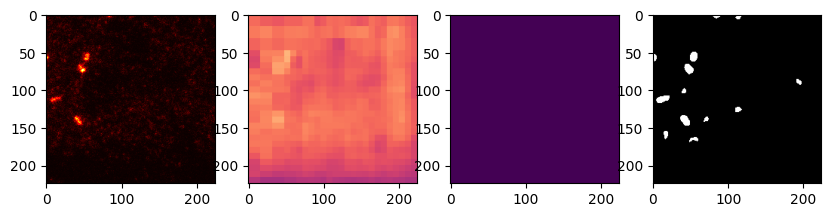

sDIV25:   0%|          | 0/186 [00:00<?, ?it/s]

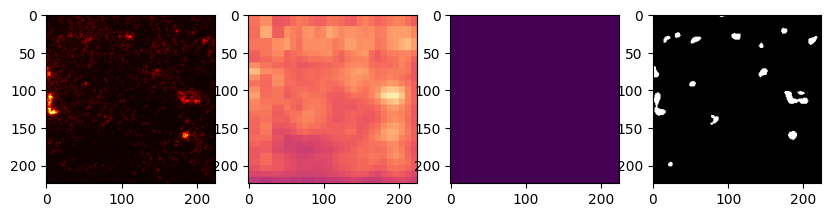

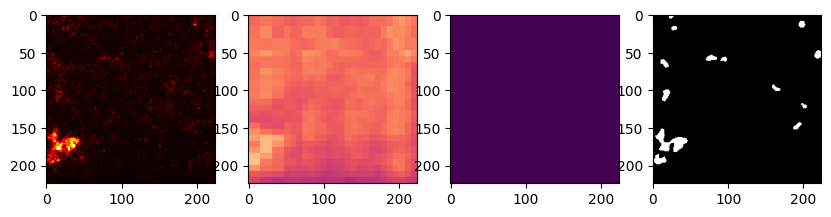

In [34]:
THRESHOLD = 0.65
scores = defaultdict(list)
for condition, metadata_per_condition in metadata.items():
    for i, metadata_per_image in enumerate(tqdm(metadata_per_condition, desc=condition)):
        foreground, label = load_images(metadata_per_image, show=i<2, threshold=THRESHOLD)
        if foreground is None:
            continue
        score = compute_scores(foreground, label)
        score["num-proteins"] = foreground.max()
        scores[condition].append(score)

defaultdict(<class 'list'>, {'sDIV12': [{'ratio': 0.0, 'num': 0, 'num-proteins': 20}, {'ratio': 0.0, 'num': 0, 'num-proteins': 13}, {'ratio': 0.0, 'num': 0, 'num-proteins': 14}, {'ratio': 0.0, 'num': 0, 'num-proteins': 25}, {'ratio': 0.0, 'num': 0, 'num-proteins': 26}, {'ratio': 0.0, 'num': 0, 'num-proteins': 16}, {'ratio': 0.0, 'num': 0, 'num-proteins': 17}, {'ratio': 0.0, 'num': 0, 'num-proteins': 14}, {'ratio': 0.0, 'num': 0, 'num-proteins': 14}, {'ratio': 0.0, 'num': 0, 'num-proteins': 11}, {'ratio': 0.0, 'num': 0, 'num-proteins': 8}, {'ratio': 0.0, 'num': 0, 'num-proteins': 12}, {'ratio': 0.0, 'num': 0, 'num-proteins': 10}, {'ratio': 0.0, 'num': 0, 'num-proteins': 8}, {'ratio': 0.0, 'num': 0, 'num-proteins': 8}, {'ratio': 0.0, 'num': 0, 'num-proteins': 11}, {'ratio': 0.0, 'num': 0, 'num-proteins': 15}, {'ratio': 0.0, 'num': 0, 'num-proteins': 12}, {'ratio': 0.0, 'num': 0, 'num-proteins': 10}, {'ratio': 0.0, 'num': 0, 'num-proteins': 10}, {'ratio': 0.0, 'num': 0, 'num-proteins': 11

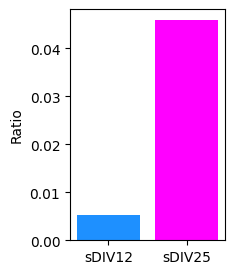

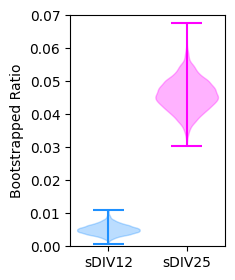

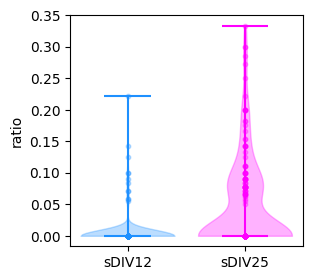

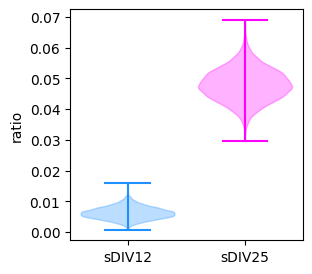

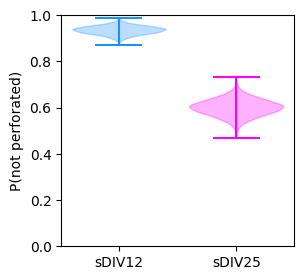

In [37]:
def plot_raw_counts(scores):
    """
    Plots the scores.

    :param scores: A dictionary with the scores
    """
    fig, ax = pyplot.subplots(1, 1, figsize=(2, 3))
    for i, (condition, values) in enumerate(scores.items()):
        counts = sum([value["num"] for value in values])
        all_proteins_counts = sum([value["num-proteins"] for value in values])
        ax.bar(i, counts / all_proteins_counts, color=COLORS[condition])    
    ax.set(
        xticks=list(range(len(scores))),
        xticklabels=list(scores.keys()),
        # ylim=(0, 2.0)
        ylabel="Ratio"
    )
    savefig(fig, f"./panels/perforated-spines/{DATASET}/raw-counts", save_white=True)
    pyplot.show()

def plot_bootstrapped_raw_counts(scores):
    """
    Plots the scores.

    :param scores: A dictionary with the scores
    """
    numpy.random.seed(42)
    fig, ax = pyplot.subplots(1, 1, figsize=(2, 3))
    distributions = {}
    for i, (condition, values) in enumerate(scores.items()):
        resampled = bootstrap([value["num"] for value in values], N=10000, func=numpy.sum)
        counts = sum([value["num"] for value in values])
        all_proteins_counts = sum([value["num-proteins"] for value in values])
        resampled = resampled / all_proteins_counts

        distributions[condition] = {
            "mean" : numpy.mean(resampled),
            "std" : numpy.std(resampled),
        }

        bplot = ax.violinplot(resampled, positions=[i], widths=0.8)
        for _, parts in bplot.items():
            if isinstance(parts, list):
                for part in parts:
                    part.set_color(COLORS[condition])
            else:
                parts.set_color(COLORS[condition])

        # ax.bar(i, numpy.mean(resampled), color=COLORS[condition], yerr=numpy.abs(numpy.quantile(resampled, [0.05, 0.95])[..., numpy.newaxis] - numpy.median(resampled)), alpha=0.3)
        # ax.bar(i, counts / all_proteins_counts, color=COLORS[condition], alpha=0.3)    
    ax.set(
        xticks=list(range(len(scores))),
        xticklabels=list(scores.keys()),
        # ylim=(0, 2.0)
        ylim=(0, 0.07),
        ylabel="Bootstrapped Ratio"
    )
    savefig(fig, f"./panels/perforated-spines/{DATASET}/raw-counts-bootstrapped", save_white=True)

    pyplot.show()

    return distributions

def plot_raw_scores(scores, name="ratio"):
    """
    Plots the scores.

    :param scores: A dictionary with the scores
    """
    fig, ax = pyplot.subplots(1, 1, figsize=(3, 3))
    for i, (condition, values) in enumerate(scores.items()):
        ratios = [value[name] for value in values]
        # bplot = ax.boxplot(ratios, positions=[i], widths=0.8, showfliers=False)
        ax.scatter([i]*len(ratios), ratios, color=COLORS[condition], alpha=0.3, s=10)
        # for _, parts in bplot.items():
        #     for part in parts:
        #         part.set_color(COLORS[condition])
        bplot = ax.violinplot(ratios, positions=[i], widths=0.8)
        for _, parts in bplot.items():
            if isinstance(parts, list):
                for part in parts:
                    part.set_color(COLORS[condition])
            else:
                parts.set_color(COLORS[condition])                
    ax.set(
        xticks=list(range(len(scores))),
        xticklabels=list(scores.keys()),
        ylabel=name,
        # ylim=(0, 2.0)
    )
    savefig(fig, f"./panels/perforated-spines/{DATASET}/raw-scores", save_white=True)
    pyplot.show()

def plot_cdf_scores(scores, name="ratio"):
    """
    Plots the scores.

    :param scores: A dictionary with the scores
    """
    fig, ax = pyplot.subplots(1, 1, figsize=(3, 3))
    for i, (condition, values) in enumerate(scores.items()):
        ratios = [value[name] for value in values]
        
        sorted_ratios = numpy.sort(ratios)
        cdf = numpy.arange(1, len(sorted_ratios)+1) / len(sorted_ratios)
        ax.plot(sorted_ratios, cdf, label=condition, color=COLORS[condition])
        
    ax.set(
        xlabel=name,
        ylabel="CDF",
        # ylim=(0, 2.0)
    )
    ax.legend()
    savefig(fig, f"./panels/perforated-spines/{DATASET}/cdf-scores", save_white=True)
    pyplot.show()    

def bootstrap(samples, N=10000, func=numpy.mean):
    """
    Computes the bootstrap scores.

    :param samples: A list of samples
    :param N: The number of bootstrap samples

    :returns : A list of bootstrap scores
    """
    choices = numpy.random.choice(samples, (N, len(samples)))
    return func(choices, axis=1)

def plot_bootstrap_scores(scores, name="ratio", N=10000):
    """
    Plots the bootstrap scores.

    :param scores: A dictionary with the scores
    :param N: The number of bootstrap samples
    """
    fig, ax = pyplot.subplots(1, 1, figsize=(3, 3))
    for i, (condition, values) in enumerate(scores.items()):
        ratios = [value[name] for value in values]
        bootstrapped = bootstrap(ratios, N=N)
        bplot = ax.violinplot(bootstrapped, positions=[i], widths=0.8)
        for _, parts in bplot.items():
            if isinstance(parts, list):
                for part in parts:
                    part.set_color(COLORS[condition])
            else:
                parts.set_color(COLORS[condition])
    ax.set(
        xticks=list(range(len(scores))),
        xticklabels=list(scores.keys()),
        ylabel=name,
        # ylim=(0., 1.0)
    )
    savefig(fig, f"./panels/perforated-spines/{DATASET}/bootstrap-ratios", save_white=True)
    pyplot.show()

def plot_probability_of_value(scores, VALUE=0.07):
    """
    Plots the probability of a value.

    :param scores: A dictionary with the scores
    :param VALUE: The value to plot
    """
    fig, ax = pyplot.subplots(1, 1, figsize=(3, 3))
    for i, (condition, values) in enumerate(scores.items()):
        ratios = numpy.array([value["ratio"] for value in values])

        choices = numpy.random.choice(ratios, (10000, len(ratios)))
        prob = numpy.mean(choices <= VALUE, axis=1)
        bplot = ax.violinplot(prob, positions=[i], widths=0.8)
        for _, parts in bplot.items():
            if isinstance(parts, list):
                for part in parts:
                    part.set_color(COLORS[condition])
            else:
                parts.set_color(COLORS[condition])
    ax.set(
        xticks=list(range(len(scores))),
        xticklabels=list(scores.keys()),
        ylabel=f"P(not perforated)",
        ylim=(0., 1.0)
    )
    savefig(fig, f"./panels/perforated-spines/{DATASET}/probability-not-perforated", save_white=True)
    pyplot.show()

print(scores)
plot_raw_counts(scores)
distributions = plot_bootstrapped_raw_counts(scores)

# standard_score = (distributions["DIV25"]["mean"] - distributions["DIV12"]["mean"]) / distributions["DIV25"]["std"]
# print("Standard score DIV25 vs DIV12:", standard_score)
# from scipy.stats import norm
# p_value = 2 * norm.cdf(-1 * abs(standard_score))
# print("P-value DIV25 vs DIV12:", p_value)

plot_raw_scores(scores, name="ratio")
plot_bootstrap_scores(scores, name="ratio")
# plot_cdf_scores(scores, name="ratio") 

plot_probability_of_value(scores, VALUE=0.0)

DIV12
Sample size: 150
DIV25
Sample size: 236
KS test p-values:
Comparing DIV12 vs DIV25: KS statistic=0.2491, p-value=1.6689e-05


  0%|          | 0/1 [00:00<?, ?it/s]

P-values:         DIV12   DIV25
DIV12 -1.0000  0.0107
DIV25  0.0107 -1.0000
F-values: None


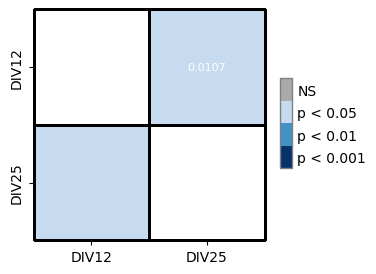

In [12]:
# Stats
from scipy.stats import ks_2samp
from stedfm.stats import resampling_stats, plot_p_values

samples = [[value["ratio"] for value in values] for condition, values in scores.items()]
for name, sample in zip(scores.keys(), samples):
    print(name,)
    print("Sample size:", len(sample))
labels = list(scores.keys())

print("KS test p-values:")
for i in range(len(samples)):
    for j in range(i+1, len(samples)):
        out = ks_2samp(samples[i], samples[j])
        print(f"Comparing {labels[i]} vs {labels[j]}: KS statistic={out.statistic:.4f}, p-value={out.pvalue:.4e}")

p_values, F_p_values = resampling_stats(samples, labels)
print("P-values:", p_values)
print("F-values:", F_p_values)
fig, ax = plot_p_values(p_values)

# savefig(fig, "./panels/factin-patches/stats", save_white=True)

DIV12
[  0 105 104 103 102  99  97  95  94  91  90  89  87  86 106  85  83  82
  79  78  77  76  75 148  73  72  70  69  68  84  65 107 110 146 144 142
 141 140 138 137 135 134 133 132 130 129 108 128 126 125 124 123 122 120
 119 118 117 116 115 114 111 127  64  74  62  37  36  35  33  63  31  26
  21  20  19  17  16  38  15  13  12  11  10   9   8   7   6   5   4   3
   1  14  39  32  55  47  59  48  49  56  46  45  58  50  60  52  53  42
  61  41  54  51  57 131 101 109  96  81 121 112  29 113  93   2  43 145
  24  22 139  80 147  88  30  40  18 149  25  67  66  71  28  44 143  23
 136  27 100  98  34  92]
0.0
0.0 0.0


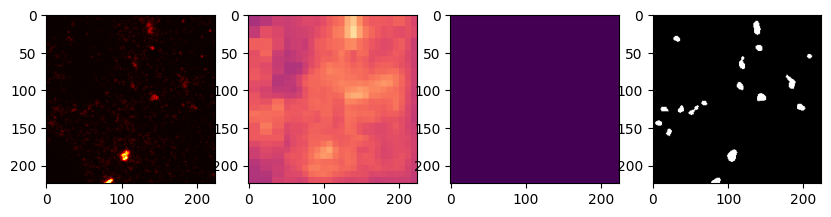

0.0 0.0


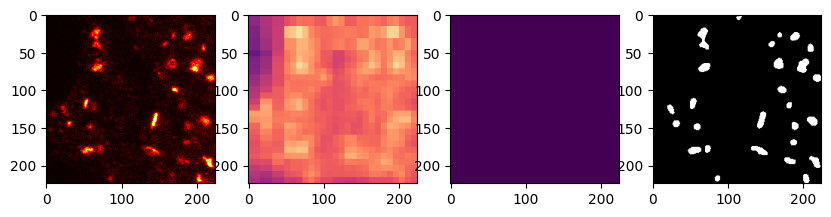

0.0 0.0


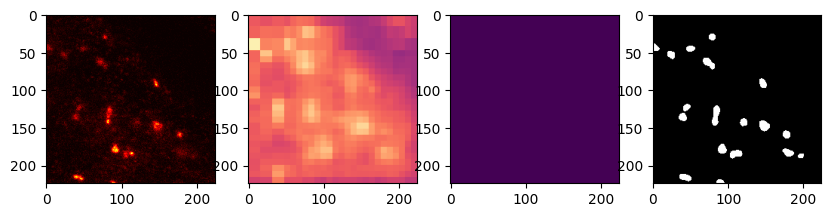

0.0 0.0


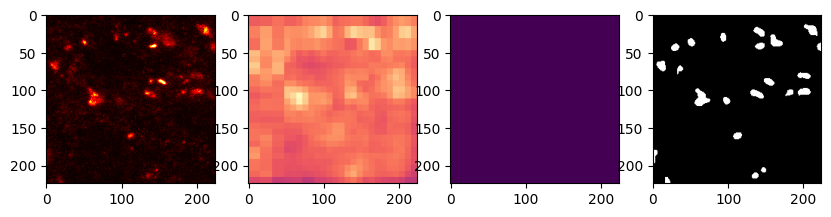

0.0 0.0


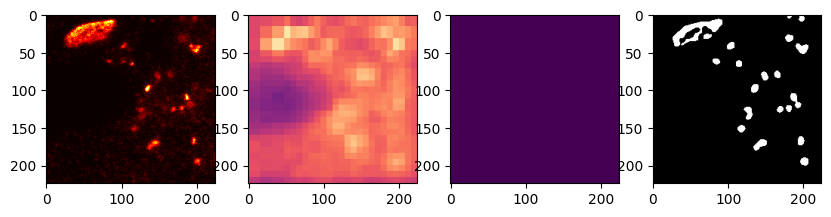

DIV25
0.1 0.0
5.tif


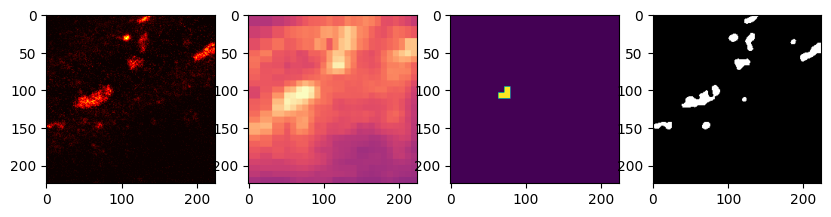

0.1 0.0
690.tif


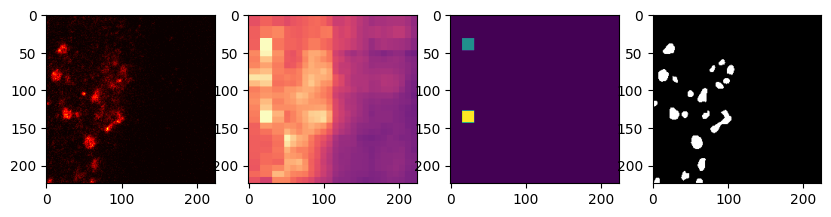

0.1 0.0
19.tif


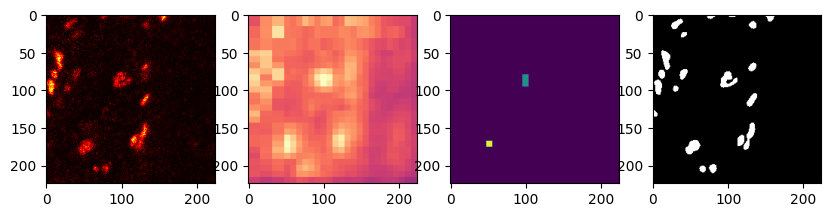

0.09523809523809523 0.004761904761904773
7.tif


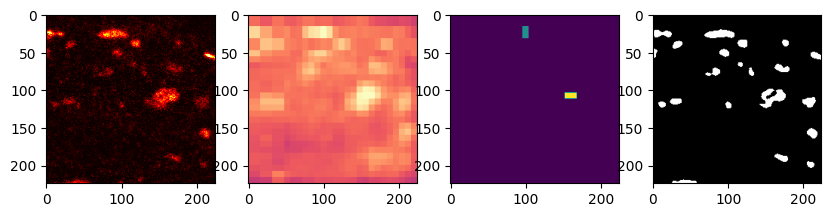

0.09523809523809523 0.004761904761904773
131.tif


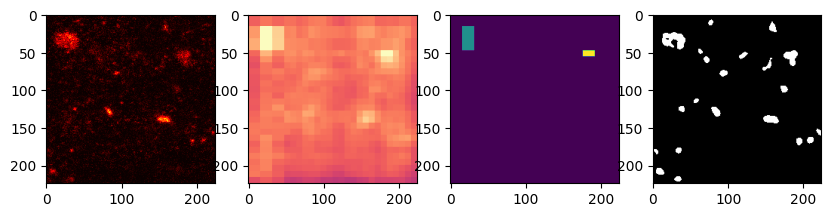

0.09523809523809523 0.004761904761904773
701.tif


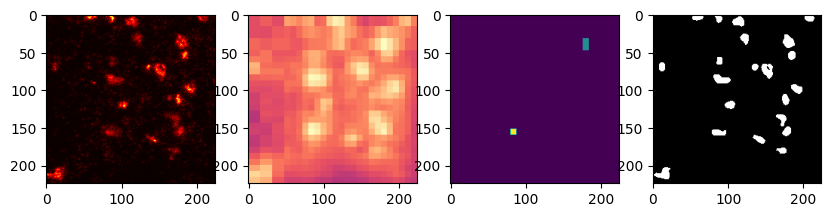

0.10714285714285714 0.007142857142857131
664.tif


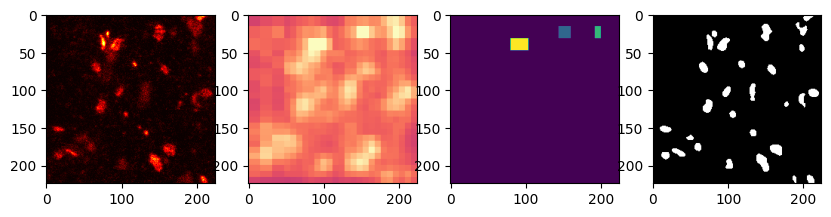

0.09090909090909091 0.009090909090909094
44.tif


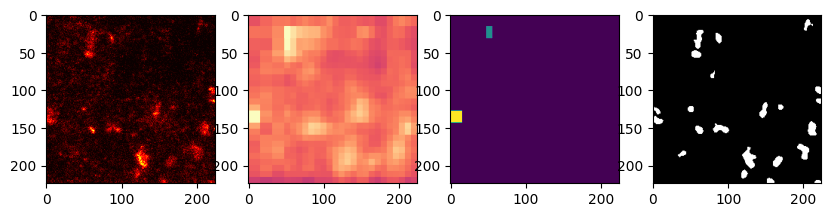

0.09090909090909091 0.009090909090909094
488.tif


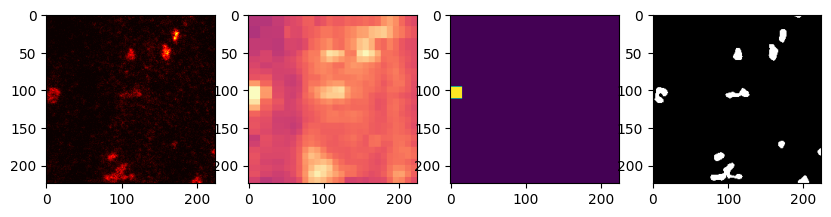

0.09090909090909091 0.009090909090909094
667.tif


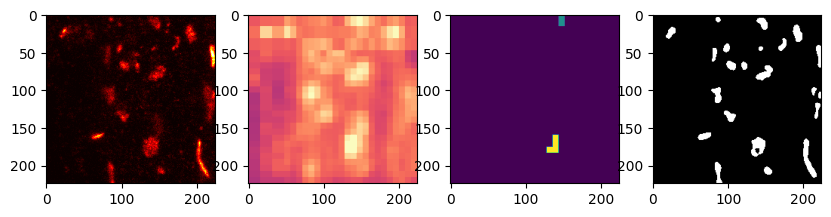

In [35]:
# Find possible examples to display

print("DIV12")

VALUE = 0.0
values = numpy.array([value["ratio"] for value in scores["DIV12"]])
differences = numpy.abs(values - VALUE)
argsorted = numpy.argsort(differences)
print(argsorted)
print(values[argsorted[0]])

for i in argsorted[:5]:
    print(values[i], differences[i])
    fg, lbl = load_images(metadata["DIV12"][i], show=True, threshold=THRESHOLD)

    # tifffile.imwrite(f"./panels/factin-patches/{metadata['DIV12'][i]['image-name']}", fg.astype(numpy.uint8) * 255)

print("DIV25")

VALUE = 0.10
values = numpy.array([value["ratio"] for value in scores["DIV25"]])
differences = numpy.abs(values - VALUE)
argsorted = numpy.argsort(differences)

for i in argsorted[:10]:
    print(values[i], differences[i])
    print(metadata["DIV25"][i]["image-name"])
    fg, lbl = load_images(metadata["DIV25"][i], show=True, threshold=THRESHOLD)
    # tifffile.imwrite(f"./panels/factin-patches/{metadata['DIV25'][i]['image-name']}", fg.astype(numpy.uint8) * 255)

# Annotations

In [209]:
# Annotation Pipeline for Perforated Spines
import pandas as pd
import random
from IPython.display import clear_output, display

class AnnotationPipeline:
    def __init__(self, metadata, threshold=0.60):
        """
        Initialize the annotation pipeline.
        
        :param metadata: Dictionary with conditions and their metadata
        :param threshold: Threshold for binarization
        """
        self.metadata = metadata
        self.threshold = threshold
        self.annotations = []
        self.current_idx = 0
        self.all_images = self._build_image_list()

        random.seed(42)
        random.shuffle(self.all_images)
        
    def _build_image_list(self):
        """Build a flat list of all images with their condition."""
        images = []
        for condition, image_list in self.metadata.items():
            for idx, img_meta in enumerate(image_list):
                images.append({
                    'condition': condition,
                    'metadata_idx': idx,
                    'metadata': img_meta
                })
        return images
    
    def display_current_image(self):
        """Display the current image and collect annotation."""
        if self.current_idx >= len(self.all_images):
            print("\n" + "="*60)
            print("ANNOTATION COMPLETE!")
            print("="*60)
            self.save_annotations()
            return False
        
        img_info = self.all_images[self.current_idx]
        condition = img_info['condition']
        metadata = img_info['metadata']
        
        # Load and display image
        foreground, label = load_images(metadata, show=False, threshold=self.threshold)
        
        # Create display
        fig, ax = pyplot.subplots(figsize=(5, 5))
        
        # Load original image for reference
        original = tifffile.imread(os.path.join(BASE_PATH, metadata["original-path"]))
        prediction = tifffile.imread(os.path.join(BASE_PATH, metadata["savepath"]))[1]
        
        ax.imshow(original, cmap="hot")
        ax.set_title("Original Image")
        ax.axis('off')
        
        # axes[1].imshow(prediction, cmap="magma", vmin=0, vmax=self.threshold)
        # axes[1].set_title("Prediction")
        # axes[1].axis('off')
        
        # axes[1, 0].imshow(label, cmap="nipy_spectral")
        # axes[1, 0].set_title("Detected Spines")
        # axes[1, 0].axis('off')
        
        # axes[1, 1].imshow(foreground, cmap="gray")
        # axes[1, 1].set_title("Foreground")
        # axes[1, 1].axis('off')
        
        fig.suptitle(
            f"Image {self.current_idx + 1}/{len(self.all_images)}",
            fontsize=14,
            fontweight='bold'
        )
        pyplot.tight_layout()
        pyplot.show()
        
        return True
    
    def annotate_current(self, value):
        """Record annotation for current image."""
        try:
            annotation_value = float(value)
            img_info = self.all_images[self.current_idx]
            
            self.annotations.append({
                'image_index': self.current_idx,
                'condition': img_info['condition'],
                'metadata_idx': img_info['metadata_idx'],
                'image_name': img_info['metadata'].get('image-name', 'N/A'),
                'original_path': img_info['metadata'].get('original-path', 'N/A'),
                'annotation': annotation_value
            })
            
            print(f"✓ Annotation recorded: {annotation_value}")
            self.current_idx += 1
            
            # Display next image
            clear_output(wait=False)
            if self.display_current_image():
                print("\nEnter your annotation (numeric value) and press Enter to continue:")
            
        except ValueError:
            print("Invalid input. Please enter a numeric value.")
    
    def save_annotations(self):
        """Save annotations to CSV and return as DataFrame."""
        df = pd.DataFrame(self.annotations)
        df.to_csv('annotations.csv', index=False)
        print(f"\nAnnotations saved to 'annotations.csv'")
        print(f"Total annotations: {len(self.annotations)}")
        print("\nAnnotation Summary:")
        print(df.groupby('condition')['annotation'].describe())
        return df
    
    def start(self):
        """Start the annotation pipeline."""
        print("="*60)
        print("ANNOTATION PIPELINE")
        print("="*60)
        print(f"Total images to annotate: {len(self.all_images)}")
        print(f"Conditions: {list(self.metadata.keys())}")
        print("="*60)
        print("\nEnter your annotation (numeric value) and press Enter to continue:")
        
        self.display_current_image()

# Initialize and start the annotation pipeline
annotation_pipeline = AnnotationPipeline(metadata, threshold=THRESHOLD)

ANNOTATION PIPELINE
Total images to annotate: 386
Conditions: ['DIV12', 'DIV25']

Enter your annotation (numeric value) and press Enter to continue:


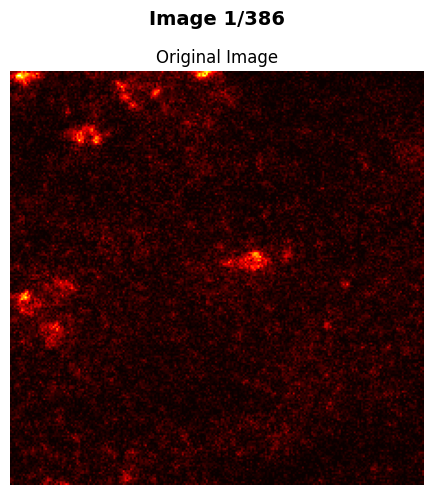

In [212]:
# Start the annotation pipeline
annotation_pipeline.start()

In [ ]:
# Interactive annotation input loop
import ipywidgets as widgets
from IPython.display import display, HTML

# Create input widget
annotation_input = widgets.FloatText(
    value=0.0,
    description='Annotation:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='200px')
)

skip_button = widgets.Button(
    description='Skip',
    button_style='warning',
    tooltip='Skip this image without annotation',
    layout=widgets.Layout(width='100px')
)

submit_button = widgets.Button(
    description='Submit',
    button_style='success',
    tooltip='Submit annotation and continue to next image',
    layout=widgets.Layout(width='100px')
)

undo_button = widgets.Button(
    description='Undo',
    button_style='info',
    tooltip='Go back to previous image',
    layout=widgets.Layout(width='100px')
)

status_output = widgets.Output()

def on_submit_click(b):
    with status_output:
        value = annotation_input.value
        annotation_pipeline.annotate_current(value)
        annotation_input.value = 0.0

def on_skip_click(b):
    with status_output:
        print("⊘ Skipped this image")
        annotation_pipeline.current_idx += 1
        clear_output(wait=False)
        if annotation_pipeline.display_current_image():
            annotation_input.value = 0.0
        else:
            print("\nAnnotation pipeline complete!")

def on_undo_click(b):
    with status_output:
        if annotation_pipeline.annotations:
            last_annotation = annotation_pipeline.annotations.pop()
            annotation_pipeline.current_idx -= 1
            print(f"↶ Removed last annotation for: {last_annotation['image_name']}")
            clear_output(wait=False)
            if annotation_pipeline.display_current_image():
                annotation_input.value = 0.0
        else:
            print("No annotations to undo.")

submit_button.on_click(on_submit_click)
skip_button.on_click(on_skip_click)
undo_button.on_click(on_undo_click)

# Display controls
control_box = widgets.HBox([annotation_input, submit_button, skip_button, undo_button])
display(HTML("<h3>Annotation Controls</h3>"))
display(control_box)
display(status_output)

Output()

In [219]:
# Review and export annotations
def review_annotations():
    """Display summary statistics of collected annotations."""
    if not annotation_pipeline.annotations:
        print("No annotations collected yet.")
        return
    
    df = pd.DataFrame(annotation_pipeline.annotations)
    
    print("\n" + "="*60)
    print("ANNOTATION SUMMARY")
    print("="*60)
    print(f"Total annotations: {len(df)}")
    print(f"\nAnnotations by condition:")
    print(df.groupby('condition')['annotation'].agg(['count', 'mean', 'std', 'min', 'max']))
    
    print(f"\nOverall statistics:")
    print(df['annotation'].describe())
    
    print(f"\nFirst few annotations:")
    print(df.head(10))
    
    return df

# Call this function to review annotations at any time
review_df = review_annotations()


ANNOTATION SUMMARY
Total annotations: 291

Annotations by condition:
           count      mean       std  min  max
condition                                     
DIV12        109  0.192661  0.499575  0.0  2.0
DIV25        182  0.280220  0.607089  0.0  3.0

Overall statistics:
count    291.000000
mean       0.247423
std        0.569893
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        3.000000
Name: annotation, dtype: float64

First few annotations:
   image_index condition  metadata_idx image_name  \
0            0     DIV12            93   1373.tif   
1            1     DIV25            30    125.tif   
2            2     DIV25           202    703.tif   
3            3     DIV25            71     34.tif   
4            4     DIV25           186     69.tif   
5            5     DIV25            68     31.tif   
6            6     DIV25            77      4.tif   
7            7     DIV25             2     10.tif   
8            8     DIV12   

In [220]:
annotation_pipeline.save_annotations()


Annotations saved to 'annotations.csv'
Total annotations: 291

Annotation Summary:
           count      mean       std  min  25%  50%  75%  max
condition                                                    
DIV12      109.0  0.192661  0.499575  0.0  0.0  0.0  0.0  2.0
DIV25      182.0  0.280220  0.607089  0.0  0.0  0.0  0.0  3.0


,image_index,condition,metadata_idx,image_name,original_path,annotation
0,0,DIV12,93,1373.tif,detection-data/als-experiment-train/DIV12/1373...,0.0
1,1,DIV25,30,125.tif,detection-data/als-experiment-train/DIV25/125.tif,0.0
2,2,DIV25,202,703.tif,detection-data/als-experiment-train/DIV25/703.tif,0.0
3,3,DIV25,71,34.tif,detection-data/als-experiment-train/DIV25/34.tif,0.0
4,4,DIV25,186,69.tif,detection-data/als-experiment-train/DIV25/69.tif,0.0
...,...,...,...,...,...,...
286,286,DIV25,105,47.tif,detection-data/als-experiment-train/DIV25/47.tif,0.0
287,287,DIV25,139,60.tif,detection-data/als-experiment-train/DIV25/60.tif,0.0
288,288,DIV25,143,64.tif,detection-data/als-experiment-train/DIV25/64.tif,0.0
289,289,DIV12,108,1388.tif,detection-data/als-experiment-train/DIV12/1388...,0.0


In [239]:
import pandas
annotations = pandas.read_csv("annotations-ab.csv")
ratios = []
for name, group in annotations.groupby("condition"):
    num_proteins = group["annotation"].sum()
    print(f"Condition: {name}, Number of proteins: {num_proteins}")

    all_proteins = sum([value['num-proteins'] for value in scores[name]])
    print(f"All detected proteins: {all_proteins}")
    print(f"Ratio of annotated to detected proteins: {num_proteins / all_proteins if all_proteins else 0}")

    ratios.append(num_proteins / all_proteins if all_proteins else 0)

print((ratios[1] - ratios[0]) / (ratios[0]))

Condition: DIV12, Number of proteins: 28.0
All detected proteins: 1794
Ratio of annotated to detected proteins: 0.01560758082497213
Condition: DIV25, Number of proteins: 60.0
All detected proteins: 3930
Ratio of annotated to detected proteins: 0.015267175572519083
-0.021810250817884482
